# **Homework 2**

**Questo homework ha l’obiettivo di affrontare un problema di classificazione, cercando di ottenere le migliori prestazioni possibili, utilizzando i modelli e le metodologie viste a lezione.**

**Il dataset da utilizzare è CIFAR10: contiene 60,000 immagini (50,000 di training e 10,000 di test) divise in 10 classi, a risoluzione 32x32 pixel, a colori. Questa è la pagina di riferimento del dataset.**

**Nello specifico, i requisiti dell’homework sono:caricare correttamente il dataset CIFAR10;utilizzare i seguenti modelli di classificazione: regressione logistica, k-NN, SVM, decision tree;effettuare opportunamente la model selection;riportare le prestazioni ottenuti, secondo le metriche di valutazione appropriate.**

**La strategia di esecuzione di ciascuna di queste fasi è a scelta dello studente. La valutazione dell’homework terrà conto della correttezza metodologica, della correttezza dell’implementazione e della completezza dell’approccio di ricerca del modello migliore.**

**Nel caso in cui l’allenamento dei modelli risulti eccessivamente dispensioso in termini di tempo, è possibile valutare l’ipotesi di sotto-campionamento del dataset.**


> ***IMPORTAZIONE DELLE LIBRERIE***

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from tqdm import tqdm


>  ***Definisco la funzione (presente nella documentazione) per caricare i batch di dati***

In [3]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

>  ***Definisco i path dei file (caricati direttamente qui su kaggle) e chiamo la funzione prima definita***

In [4]:
batches_meta = '/kaggle/input/file-uploaded/cifar-10-batches-py/batches.meta'#file che contiene le labels associate alle cifre 0-9
test_batch= '/kaggle/input/file-uploaded/cifar-10-batches-py/test_batch' #batch da usare per il test
data_path = '/kaggle/input/file-uploaded/cifar-10-batches-py/' #percorso che contiene tutte le batch di dati

meta=unpickle(batches_meta)
test=unpickle(test_batch)

#'b' sta per la codifica in bytes
X_test_tot=test[b'data'] #prendo i dati dal test_batch
y_test_tot = test[b'labels'] #prendo le label dal test_batch

label_names = meta[b'label_names']  # è una lista di byte string
label_names = [label.decode('utf-8') for label in label_names]  # decodifica da byte a str per comprendere le labels

> ***Caricamento del dataset***

In [5]:
X_train_list = []
y_train_list = []

#caricamento dei 5 data batch
#ogni batch contiene 10000 immagini, ognuna con 3072 caratteristiche (32(altezza)*32(larghezza)*3(RGB))
for i in range(1, 6):
    batch_file = f'{data_path}data_batch_{i}' #specifico il path
    batch = unpickle(batch_file) #chiamo la funzione
    X_train_list.append(batch[b'data']) #aggiungo alla list la batch di dati
    y_train_list.append(batch[b'labels']) #stessa cosa per le label

#creiamo un unico trainset concatenando i vari data_batch 
X_train_tot = np.concatenate(X_train_list)
y_train_tot = np.concatenate(y_train_list)

print(f'Dimensione di X_train_tot: {X_train_tot.shape}') 
print(f'Dimensione di y_train_tot: {y_train_tot.shape}')


Dimensione di X_train_tot: (50000, 3072)
Dimensione di y_train_tot: (50000,)


> **Standardizzo i dati e applico la PCA per la feature reduction**

*Applico la pca poiche allenare il modello con 3072 caratteristiche per ogni immagine era temporalmente troppo costoso:*
>  per la pca, definisco n_components=0.90/0.95,
>  la PCA viene applicata in modo da tenere le feature che complessivamente spiegano almeno il 90/95% del dataset

In [6]:
#ho usato queste linee di codice per considerare l'intero dataset (50000) oppure scalarlo per vedere
#come cambiano i risultati al variare del numero delle feature del dataset
X_train = X_train_tot[:50000]
y_train = y_train_tot[:50000]


X_test = X_test_tot[:10000]
y_test = y_test_tot[:10000]

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

#Standardizzo i dati:
scaler=StandardScaler()
X_train_std_x=scaler.fit_transform(X_train)
X_test_std_x=scaler.transform(X_test)

#PCA:
n_components = 0.95
pca = PCA(n_components=n_components)
X_train_std = pca.fit_transform(X_train_std_x)
X_test_std = pca.transform(X_test_std_x)

print(f"Nuova forma delle feature di training dopo PCA: {X_train_std.shape}")
print(f"Nuova forma delle feature di test dopo PCA: {X_test_std.shape}")

Training set shape: (50000, 3072)
Test set shape: (10000, 3072)
Nuova forma delle feature di training dopo PCA: (50000, 221)
Nuova forma delle feature di test dopo PCA: (10000, 221)


>  **DEFINISCO I DIZIONARI:**
> 
> *-Dizionario per la definizione dei modelli da testare*
> 
> *-Dizionari per la definizioni dei parametri per ogni modello*
> 
*In questo modo posso provare ogni modello con diverse configurazioni in modo da trovare le migliori opzioni*

In [7]:
# ogni modello che vogliamo testare
models = {
    'LogisticRegression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(),
    'SVM': SVC()
}

#parametri per ogni modello
param_grids = {
    'LogisticRegression': {
        'max_iter': [1000,5000,10000],
        'C': [0.01,0.1,1, 10],
        'solver': ['liblinear']  
    },
    'SVM': {
        'C': [0.01,0.1],
        'kernel': ['linear', 'poly', 'rbf']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'chebyshev','minkowski']
    },
    'DecisionTree': {
        'max_depth': [5, 7, 9, None],
        'min_samples_split': [5, 10, 15],
        'min_samples_leaf': [2, 4, 6],
        'criterion': ['entropy']
    }
}

#qui mettero i migliori modelli
best_models = {}
#qui i migliori scores
best_scores = {}
#qui i migliori parametri
best_params = {}

> **ALLENAMENTO DEI MODELLI**

Model Selection:   0%|          | 0/4 [00:00<?, ?it/s]

Allenamento e ricerca parametri per LogisticRegression...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ............C=0.01, max_iter=1000, solver=liblinear; total time=  55.3s
[CV] END ............C=0.01, max_iter=1000, solver=liblinear; total time=  57.7s
[CV] END ............C=0.01, max_iter=1000, solver=liblinear; total time=  57.2s
[CV] END ............C=0.01, max_iter=5000, solver=liblinear; total time=  56.7s
[CV] END ............C=0.01, max_iter=5000, solver=liblinear; total time=  58.7s
[CV] END ............C=0.01, max_iter=5000, solver=liblinear; total time=  57.9s
[CV] END ...........C=0.01, max_iter=10000, solver=liblinear; total time=  56.4s
[CV] END ...........C=0.01, max_iter=10000, solver=liblinear; total time=  59.0s
[CV] END ...........C=0.01, max_iter=10000, solver=liblinear; total time=  58.0s
[CV] END .............C=0.1, max_iter=1000, solver=liblinear; total time= 1.0min
[CV] END .............C=0.1, max_iter=1000, solver=liblinear; total tim

Model Selection:   0%|          | 0/4 [38:22<?, ?it/s]

Completato: LogisticRegression


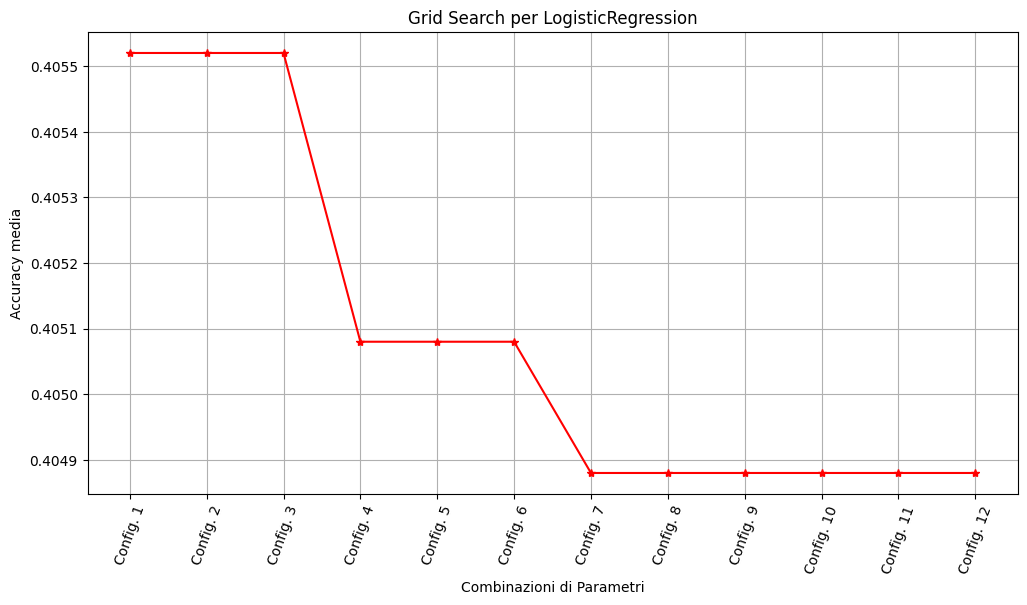

Model Selection:  25%|██▌       | 1/4 [38:23<1:55:09, 2303.27s/it]

Allenamento e ricerca parametri per KNN...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   5.5s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   5.4s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   5.4s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   4.8s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   5.4s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   4.7s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   5.4s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   5.4s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   5.4s
[CV] END ..metric=euclidean, n_neighbors=5, weights=distance; total time=   4.7s
[CV] END ..metric=euclidean, n_neighbors=5, weights=distance; total time=   5.5s
[CV] 

Model Selection:  25%|██▌       | 1/4 [1:14:00<1:55:09, 2303.27s/it]

[CV] END ..metric=minkowski, n_neighbors=7, weights=distance; total time=   4.8s
Completato: KNN


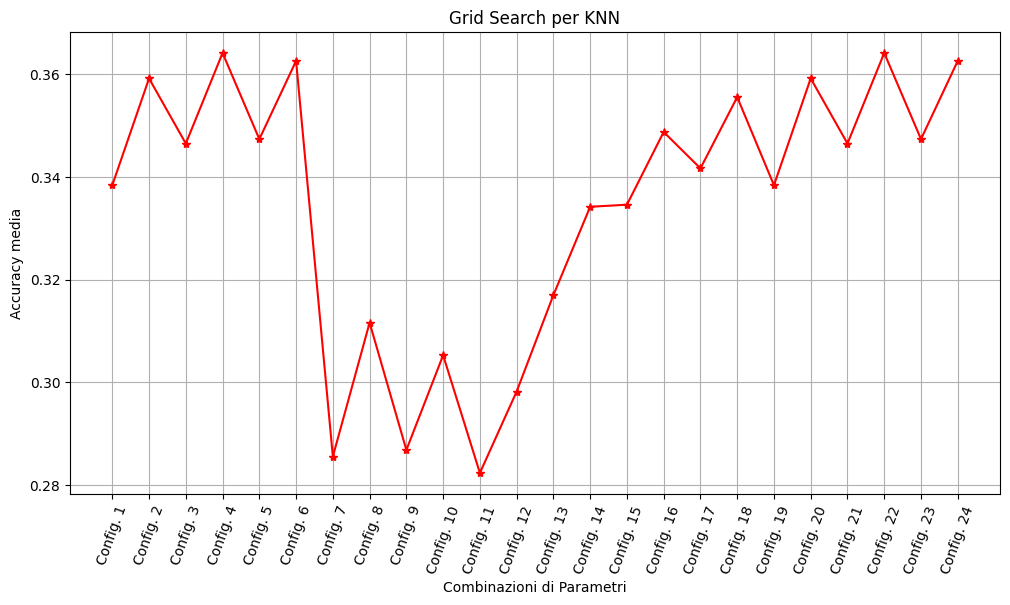

Model Selection:  50%|█████     | 2/4 [1:14:01<1:13:31, 2205.89s/it]

Allenamento e ricerca parametri per DecisionTree...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END criterion=entropy, max_depth=5, min_samples_leaf=2, min_samples_split=5; total time=  15.5s
[CV] END criterion=entropy, max_depth=5, min_samples_leaf=2, min_samples_split=5; total time=  15.4s
[CV] END criterion=entropy, max_depth=5, min_samples_leaf=2, min_samples_split=5; total time=  15.5s
[CV] END criterion=entropy, max_depth=5, min_samples_leaf=2, min_samples_split=10; total time=  15.4s
[CV] END criterion=entropy, max_depth=5, min_samples_leaf=2, min_samples_split=10; total time=  15.5s
[CV] END criterion=entropy, max_depth=5, min_samples_leaf=2, min_samples_split=10; total time=  15.4s
[CV] END criterion=entropy, max_depth=5, min_samples_leaf=2, min_samples_split=15; total time=  15.6s
[CV] END criterion=entropy, max_depth=5, min_samples_leaf=2, min_samples_split=15; total time=  15.4s
[CV] END criterion=entropy, max_depth=5, min_samples_leaf=2, min_samples_

Model Selection:  50%|█████     | 2/4 [1:59:12<1:13:31, 2205.89s/it]

Completato: DecisionTree


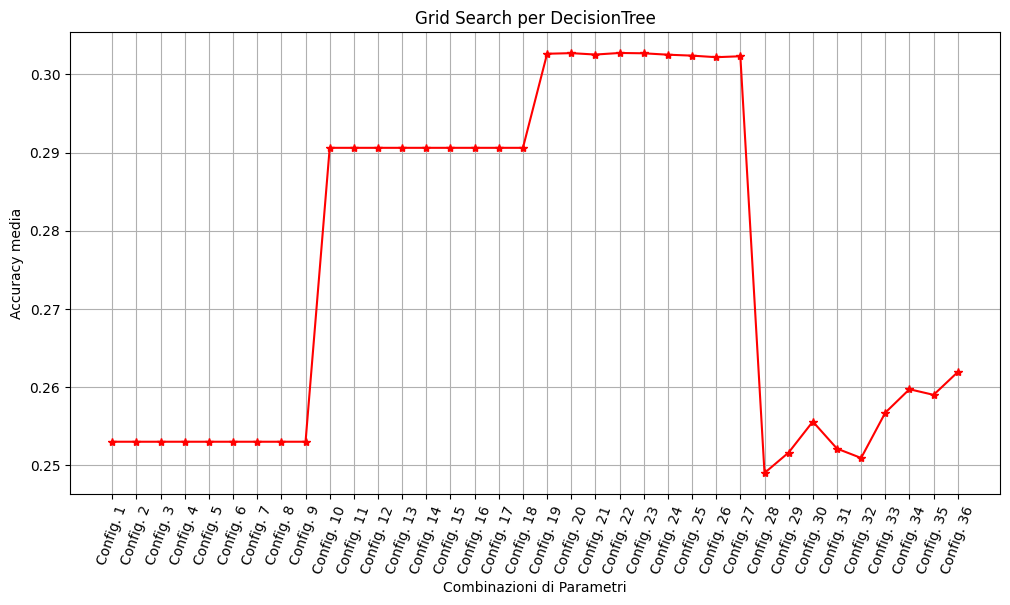

Model Selection:  75%|███████▌  | 3/4 [1:59:13<40:37, 2437.03s/it]  

Allenamento e ricerca parametri per SVM...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ..............................C=0.01, kernel=linear; total time= 8.6min
[CV] END ..............................C=0.01, kernel=linear; total time= 8.7min
[CV] END ..............................C=0.01, kernel=linear; total time= 8.5min
[CV] END ................................C=0.01, kernel=poly; total time= 8.6min
[CV] END ................................C=0.01, kernel=poly; total time= 8.3min
[CV] END ................................C=0.01, kernel=poly; total time= 8.4min
[CV] END .................................C=0.01, kernel=rbf; total time=10.6min
[CV] END .................................C=0.01, kernel=rbf; total time=10.5min
[CV] END .................................C=0.01, kernel=rbf; total time=10.6min
[CV] END ...............................C=0.1, kernel=linear; total time=29.8min
[CV] END ...............................C=0.1, kernel=linear; total time=29.3min
[CV] E

Model Selection:  75%|███████▌  | 3/4 [5:51:36<40:37, 2437.03s/it]

Completato: SVM


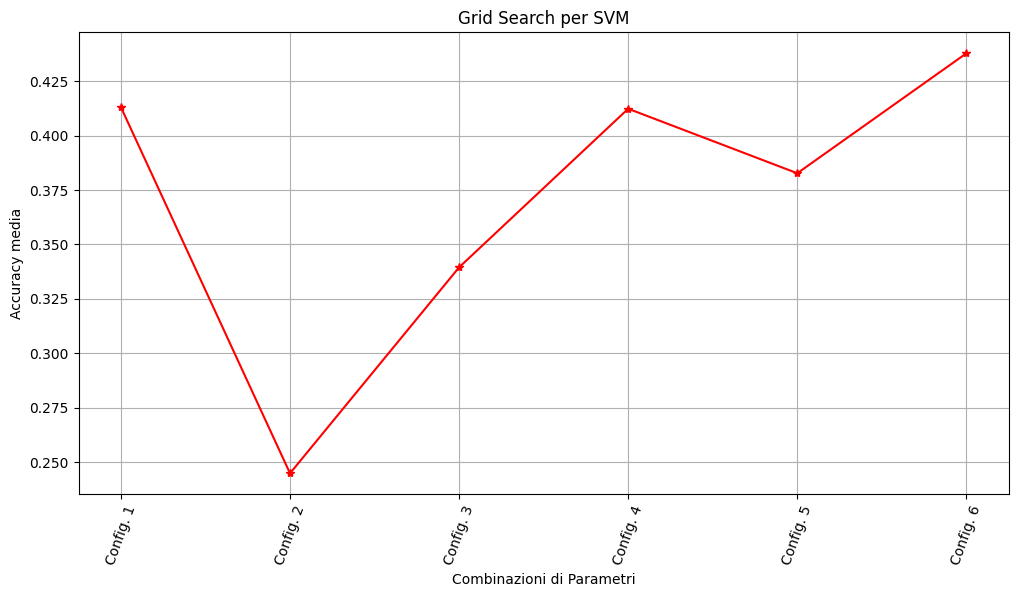

Model Selection: 100%|██████████| 4/4 [5:51:37<00:00, 5274.26s/it]


In [9]:
#iterazione
#tqdm é una caratteristica che ho voluto aggiungere per una migliore visualizzazione dei risultati,corrisponde ad una "barra d'avanzamaneto"
for model_name in tqdm(models, desc="Model Selection"): 
    print(f"Allenamento e ricerca parametri per {model_name}...")
    
    model = models[model_name] #definisco il modello da usare
    param_grid = param_grids[model_name] #definisco i parametri da usare

    
    #applico la gridsearch per allenare il modello ed eseguire la cross-validation
    #pongo cv=3 per fare cross-validation con 3 fold, la baso sull'accuracy
    #n_jobs=-1 serve per usare tutti i core della CPU, n_jobs=1 per avere un'esecuzione lineare usando la singola CPU
    #verbose=2 serve per mostrare dettagli durante l'esecuzione cosi da capire cosa succede durante l'allenamento
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=1, verbose=2) 
    grid_search.fit(X_train_std, y_train)
    
    # salvo il miglior modello, score e parametri
    best_models[model_name] = grid_search.best_estimator_
    best_scores[model_name] = grid_search.best_score_
    best_params[model_name] = grid_search.best_params_

    tqdm.write(f"Completato: {model_name}")

    #PLOT dei risultati generali (per avere un minimo di visualizzazione)
    results = grid_search.cv_results_
    mean_test_scores = results['mean_test_score']
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(mean_test_scores)), mean_test_scores, marker='*', color='red')
    plt.title(f'Grid Search per {model_name}')
    plt.xlabel('Combinazioni di Parametri')
    plt.ylabel('Accuracy media')
    n_combinazioni=len(mean_test_scores)
    combinazioni_labels = [] #mi serviva per azzerare le etichette, altrimenti ogni volta che facevo debug le labels aumentavano
    #cambiare il nome(labels) dell'asse x
    for i in range(n_combinazioni):
        combinazioni_labels.append(f'Config. {i+1}')
    plt.xticks(range(n_combinazioni), combinazioni_labels, rotation=70)
    plt.grid(True)
    plt.show()

> **Visualizzazione risultati finali dopo allenamento:**
> 
> *Stampo le configurazioni migliori per ogni modello, le matrici di confusione per ogni miglior modello ed infine il modello migliore in assoluto*


 Migliori modelli:

Modello: LogisticRegression
  - Migliori parametri: {'C': 0.01, 'max_iter': 1000, 'solver': 'liblinear'}
  - Miglior Cross-Validation Accuracy: 0.4055
----------------------------------------------------------------------
Modello: KNN
  - Migliori parametri: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
  - Miglior Cross-Validation Accuracy: 0.3642
----------------------------------------------------------------------
Modello: DecisionTree
  - Migliori parametri: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 4, 'min_samples_split': 5}
  - Miglior Cross-Validation Accuracy: 0.3027
----------------------------------------------------------------------
Modello: SVM
  - Migliori parametri: {'C': 0.1, 'kernel': 'rbf'}
  - Miglior Cross-Validation Accuracy: 0.4379
----------------------------------------------------------------------

Confusion Matrix per LogisticRegression:


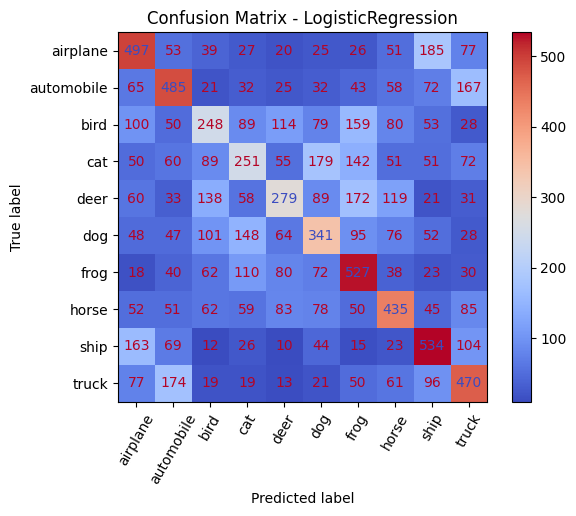

              precision    recall  f1-score   support

    airplane       0.44      0.50      0.47      1000
  automobile       0.46      0.48      0.47      1000
        bird       0.31      0.25      0.28      1000
         cat       0.31      0.25      0.28      1000
        deer       0.38      0.28      0.32      1000
         dog       0.36      0.34      0.35      1000
        frog       0.41      0.53      0.46      1000
       horse       0.44      0.43      0.44      1000
        ship       0.47      0.53      0.50      1000
       truck       0.43      0.47      0.45      1000

    accuracy                           0.41     10000
   macro avg       0.40      0.41      0.40     10000
weighted avg       0.40      0.41      0.40     10000


Confusion Matrix per KNN:


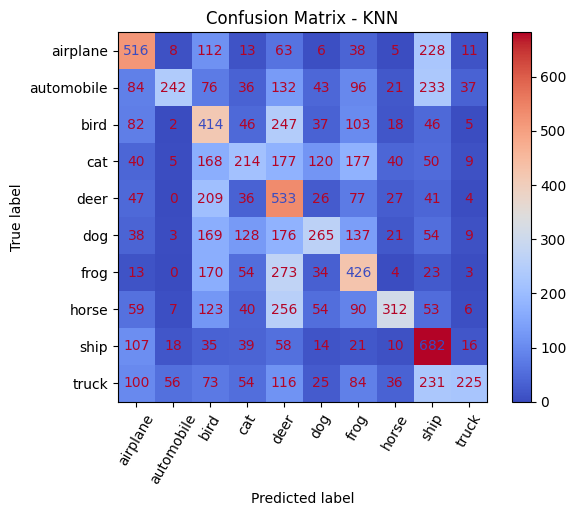

              precision    recall  f1-score   support

    airplane       0.48      0.52      0.49      1000
  automobile       0.71      0.24      0.36      1000
        bird       0.27      0.41      0.32      1000
         cat       0.32      0.21      0.26      1000
        deer       0.26      0.53      0.35      1000
         dog       0.42      0.27      0.33      1000
        frog       0.34      0.43      0.38      1000
       horse       0.63      0.31      0.42      1000
        ship       0.42      0.68      0.52      1000
       truck       0.69      0.23      0.34      1000

    accuracy                           0.38     10000
   macro avg       0.45      0.38      0.38     10000
weighted avg       0.45      0.38      0.38     10000


Confusion Matrix per DecisionTree:


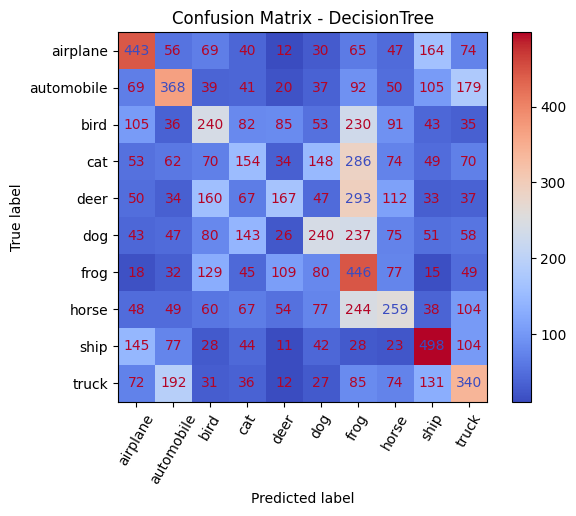

              precision    recall  f1-score   support

    airplane       0.42      0.44      0.43      1000
  automobile       0.39      0.37      0.38      1000
        bird       0.26      0.24      0.25      1000
         cat       0.21      0.15      0.18      1000
        deer       0.32      0.17      0.22      1000
         dog       0.31      0.24      0.27      1000
        frog       0.22      0.45      0.30      1000
       horse       0.29      0.26      0.28      1000
        ship       0.44      0.50      0.47      1000
       truck       0.32      0.34      0.33      1000

    accuracy                           0.32     10000
   macro avg       0.32      0.32      0.31     10000
weighted avg       0.32      0.32      0.31     10000


Confusion Matrix per SVM:


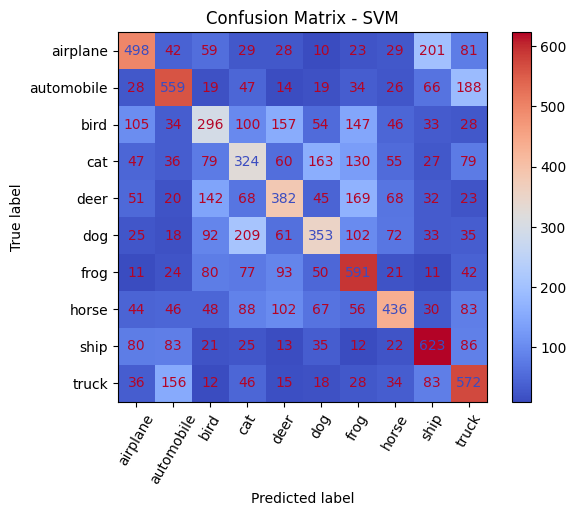

              precision    recall  f1-score   support

    airplane       0.54      0.50      0.52      1000
  automobile       0.55      0.56      0.55      1000
        bird       0.35      0.30      0.32      1000
         cat       0.32      0.32      0.32      1000
        deer       0.41      0.38      0.40      1000
         dog       0.43      0.35      0.39      1000
        frog       0.46      0.59      0.52      1000
       horse       0.54      0.44      0.48      1000
        ship       0.55      0.62      0.58      1000
       truck       0.47      0.57      0.52      1000

    accuracy                           0.46     10000
   macro avg       0.46      0.46      0.46     10000
weighted avg       0.46      0.46      0.46     10000


Miglior modello: SVM
Accuratezza su test: 0.463400


In [10]:
print("\n Migliori modelli:\n")

#stampa dei migliori modelli
for model_name in best_models.keys():
    print(f"Modello: {model_name}")
    print(f"  - Migliori parametri: {best_params[model_name]}")
    print(f"  - Miglior Cross-Validation Accuracy: {best_scores[model_name]:.4f}")
    print("-" * 70)


# confusion matrix per ogni miglior modello
for model_name, model in best_models.items():
    print(f"\nConfusion Matrix per {model_name}:")
    
    # predizione sul test set
    predizioni = model.predict(X_test_std)
    
    # creazione della confusion matrix
    cm = confusion_matrix(y_test, predizioni)
    
    matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    matrix.plot(cmap="coolwarm", xticks_rotation=60)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    #per vedere metriche aggiuntive di valutazione dei modelli stampo il report di classificazione
    print(classification_report(y_test, predizioni,target_names=label_names)) 



# trova il modello col punteggio migliore
best_model_name = max(best_scores, key=best_scores.get) #prendo il nome del modello, il parametro key serve per farmi ritornare la chiave (ossia il nome) del modello con il miglior score
best_model = best_models[best_model_name]  #salvo il modello migliore

# test accuracy
test_prediction = best_model.predict(X_test_std)
test_accuracy = accuracy_score(y_test, test_prediction)

print(f"\nMiglior modello: {best_model_name}")
print(f"Accuratezza su test: {test_accuracy:.6f}")